In [16]:
import os
from glob import glob
from itertools import product

import numpy as np
import pandas as pd
from PIL import Image
from adjustText import adjust_text
from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import cm, font_manager
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.ticker import (
    AutoMinorLocator,
    FixedLocator,
    LinearLocator,
    LogLocator,
    MultipleLocator
)

import seaborn as sns

matplotlib.rcParams['font.weight'] = "medium"
matplotlib.rcParams['axes.labelweight'] = 'medium'
matplotlib.rcParams['figure.titleweight'] = 'medium'
matplotlib.rcParams['axes.titleweight'] = 'medium'

sns.set_style('whitegrid')
sns.set(font_scale=1.1, style="ticks", font="Helvetica")

font_files = font_manager.findSystemFonts(fontpaths='/home/vladimirnoz/Projects/Codebook_Perspectives/fonts')
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

os.chdir('/home/vladimirnoz/Projects/Codebook_Perspectives/Chromatin')


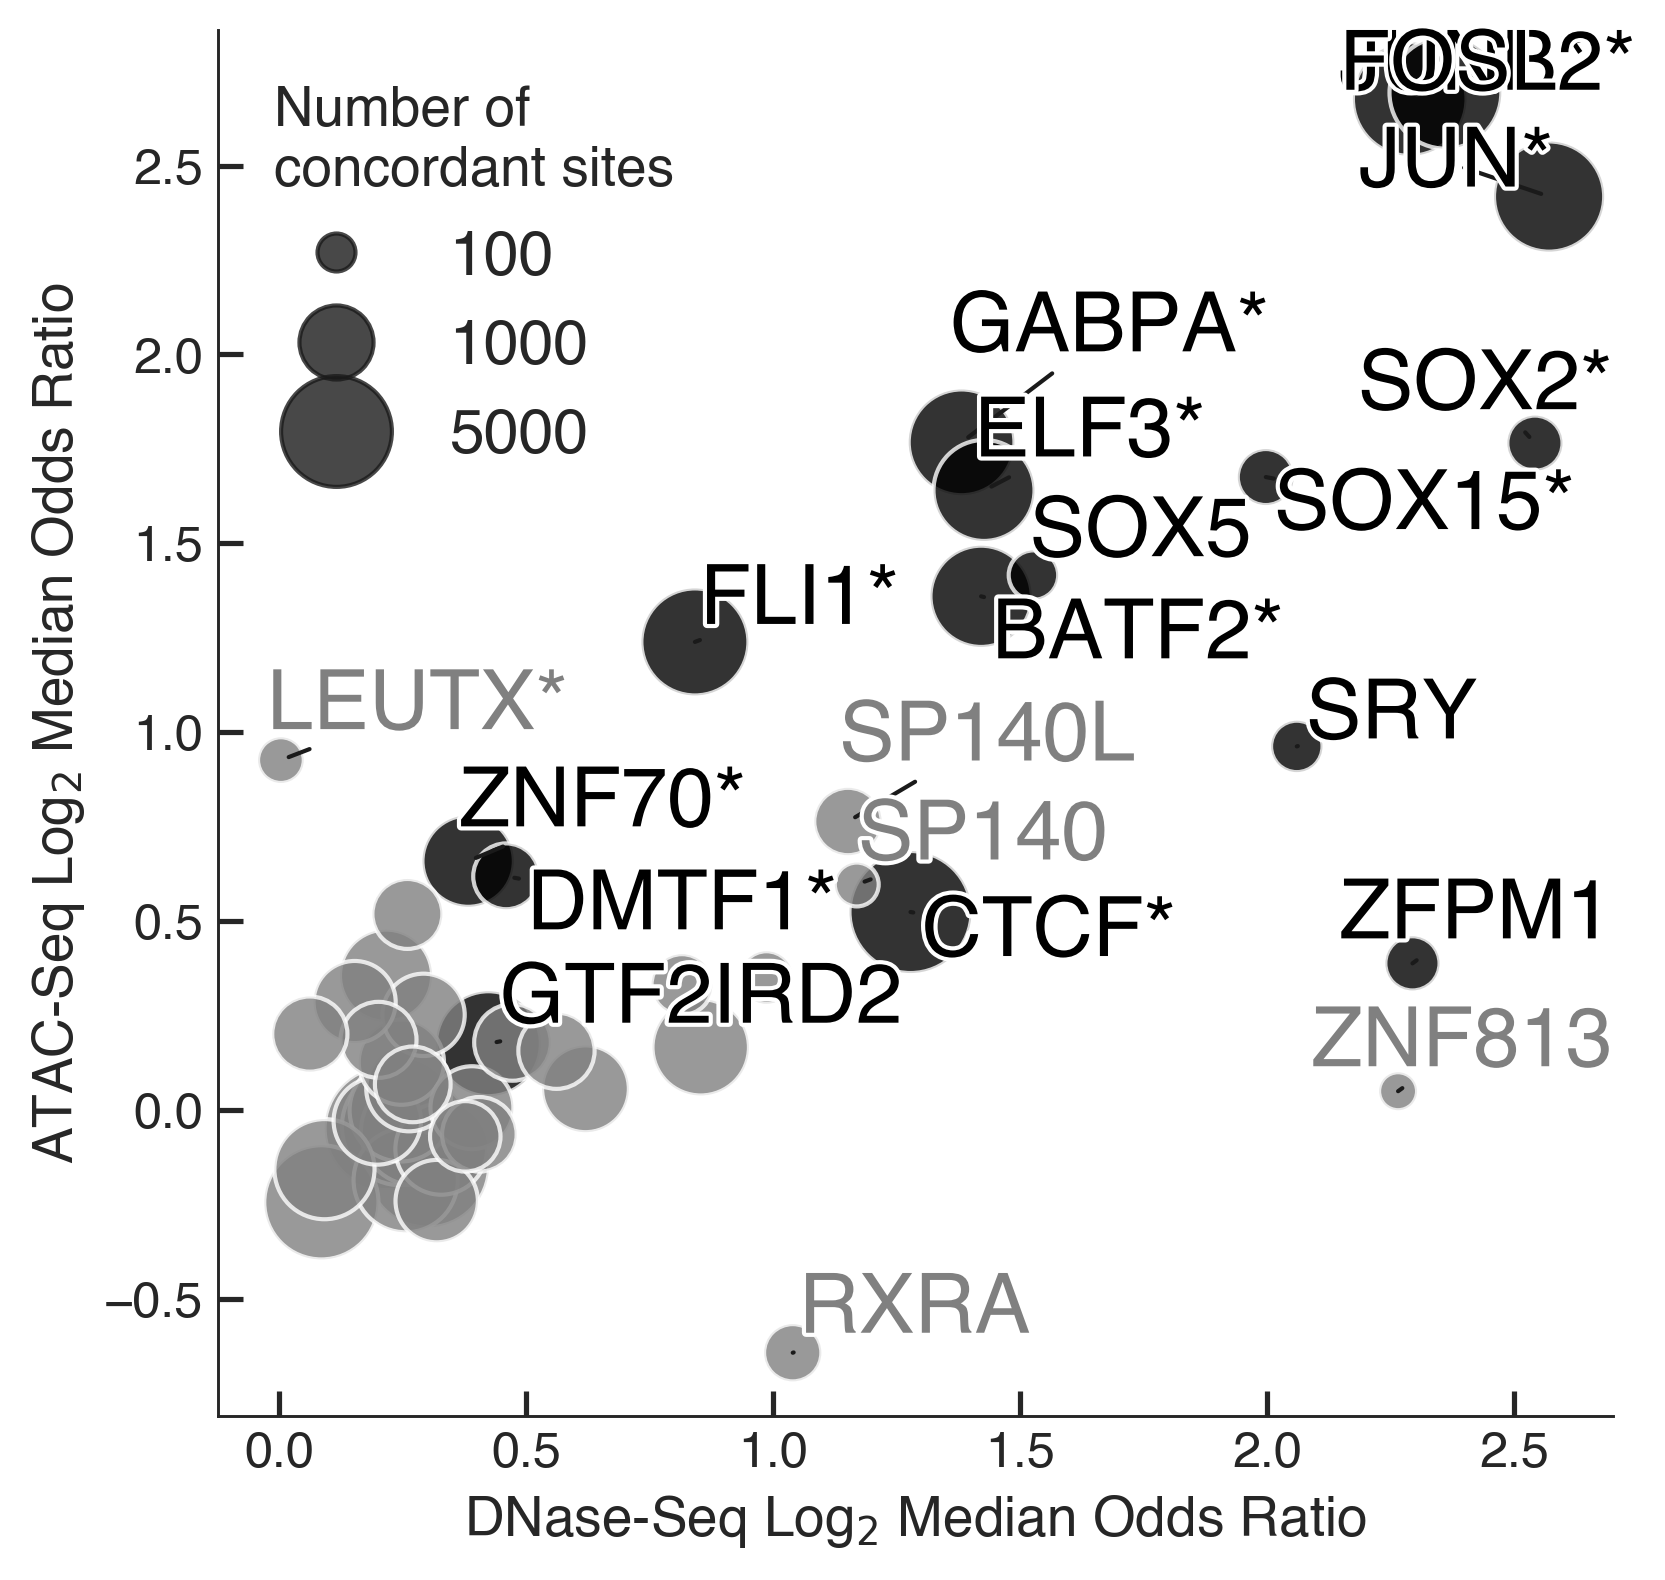

In [17]:
def change_axis_width(ax_array):
    for ax, spine in product(ax_array, ['top', 'bottom', 'right', 'left']):
        if spine in ('top', 'right'):
            w = 0
        else:
            w = 0.7
        ax.spines[spine].set_linewidth(w)

def color_list(row):
    if row['fdr_comb_atac'] < 0.05 and row['fdr_comb_dnase'] < 0.05:
        return (0, 0, 0)
    else:
        return (0.5, 0.5, 0.5)


def draw_OR(ax, annotate=False, tflist=None, good=None):
    if good is None:
        good = []
    atac = pd.read_table('agg_atac/pvalues_agg_greater.tsv')
    dnase = pd.read_table('agg_dnase/pvalues_agg_greater.tsv')
    df = atac.merge(dnase, on='TF', suffixes=('_atac', '_dnase')).query('fdr_comb_atac < 0.05 | fdr_comb_dnase < 0.05')
    df['sum_agg'] = df['agg_num_atac'] + df['agg_num_dnase']
    df['sum_conc'] = df['total_conc_dnase'] + df['total_conc_atac']
    df.sort_values(by='sum_conc', ascending=False, inplace=True)
    stat = 'median'
    f = 10
    minsize = min(df['sum_conc'])
    maxsize = max(df['sum_conc'])

    df[f'{stat}_OR_dnase'] = np.log2(df[f'{stat}_OR_dnase'])
    df[f'{stat}_OR_atac'] = np.log2(df[f'{stat}_OR_atac'])

    #df = df[(df[f'{stat}_OR_dnase'] > 0) * df[f'{stat}_OR_atac'] > 0]

    if not tflist is None:
        tflist = set(tflist)
        df['color'] = df.apply(color_list, axis=1)

    sc = ax.scatter(data=df, x=f'{stat}_OR_dnase', y=f'{stat}_OR_atac', s=np.sqrt(df['sum_conc'])*f, 
                edgecolors='w', c=df['color'], alpha=0.8)
    texts = []
    OR_thr = 1.5
    if annotate:
        for _, row in df.iterrows():
            if ((row[f'{stat}_OR_dnase'] < 1 and row[f'{stat}_OR_atac'] < 0.5) and (not (row['TF'] in tflist))
               and not (row['fdr_comb_atac'] < 0.05 and row['fdr_comb_dnase'] < 0.05) or row['TF'] in ('NFKB1', 'ZNF709')):
                continue
            tf_text = row['TF']
            if tf_text in good:
                tf_text += '*'
            text = ax.text(row[f'{stat}_OR_dnase'], row[f'{stat}_OR_atac'], tf_text,
                           path_effects=[pe.withStroke(linewidth=2, foreground="w")],
                          fontsize=20, color=row['color'])
            texts.append(text)
    adjust_text(texts=texts, arrowprops=dict(arrowstyle="-", color='k', lw=1))
    nearest  = 200
    handles = sc.legend_elements("sizes", func=lambda x: np.power(x/f, 2),
                                         num=FixedLocator([minsize, 1000, 5000, maxsize]))[0]
    labels = [100, 1000, 5000]

    leg = ax.legend(handles, labels,
                     title="Number of\nconcordant sites", frameon=False, fontsize=15)
    ax.set_xlabel('DNase-Seq Log$_{2}$' + f' {stat.capitalize()} Odds Ratio')
    ax.set_ylabel('ATAC-Seq Log$_{2}$' + f' {stat.capitalize()} Odds Ratio')
    ax.tick_params(axis='both', direction='in')
    leg._legend_box.align = "left"
    change_axis_width([ax])


tflist = ['SOX2', 'JUN', 'TPRX1', 'ZNF70']
good = ['BATF2',
 'CTCF',
 'DMTF1',
 'ELF3',
 'FLI1',
 'FOSL2',
 'GABPA',
 'JUN',
 'JUNB',
 'LEUTX',
 'SOX15',
 'SOX2',
 'SP140+SP140L',
 'ZNF70']
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
draw_OR(ax, annotate=True, tflist=tflist, good=good)
plt.savefig('figures/scatter.pdf', bbox_inches='tight')
plt.show()